## Кратко в предыдущих сериях

Советуем перед семинаром освежить в памяти:

* занятие про работу с данными: правила Sanity Check
* занятие про метрики: какие бывают метрики и какие у них свойства
* занятие про визуализации: визуализации в plotly
* Работа с датасетами в `pandas`
* ...

# Тема 6. Методы формирования гипотез из данных. Эксплуаторный анализ.

## 0. Цель и задачи

**Цель** — опираясь на знания о продукте, провести первичный анализ данных и сформулировать гипотезы о точках роста продукта.

**Задачи:** 

- узнаем, что значит "изучить данные" и понимать их структуру
- опираясь на занятие про работу с данными, научимся оценивать качество данных
- научимся выявлять аномалии и выбросы
- проведем первичный анализ данных
- научимся сегментному анализу
- поймем, как анализировать воронки
- из первичного анализа, а также знаний о продукте сформулируем гипотезы

## 1. Вспомним, что было на лекции

### 1.1 Вопрос в зал: какая структура у гипотезы?

<br>
<details>
<br>

Если мы сделаем [изменение/действие], то повлияем на [на что влияем, для какого сегмента]. Действие заметим через [название метрики], которая изменится на [n%]
    
</details>

### 1.2 Попрактикуемся в формировании гипотез

**Вспомним, что мы знаем про кейс Yxxxxx.Такси. Какие инсайты у нас уже есть?**

- На тарифах **комфорт** и **комфорт+** поездки дороже, чем **эконом**
- На тарифах **эконом** таксисты совершают больше поездок в день
- Тарифы **комфорт** и **комфорт+** иногда переключаются на **эконом**, чтобы у них были заказы
- Таксисты на **комфорт** и **комфорт+** потенциально зарабатывают больше, но разброс больше — кто-то может уехать далеко и дорого, кто-то — просто сидит без заказов. При этом эконом более стабилен, но доход ниже
- Для компании выгоднее, если таксист работает **на более дорогом тарифе** — комиссия и наценка растёт пропорционально среднему чеку
- Большинство клиентов заказывают **эконом**

### Вопрос в зал: какие гипотезы можно сгенерировать из этих инсайтов?

<br>
<details>
<br>
    
*Возможные варианты:*

> Если мы **покажем клиенту при выборе тарифа разницу во времени подачи: “эконом — 7 мин, комфорт — 3 мин”**, то повлияем на **долю клиентов, которые выбирают более дорогие тарифы**. Действие заметим через **увеличение доли заказов на Комфорт/Комфорт+**, которая может вырасти на **5–8%**, а также через увеличение **среднего чека**, который вырастет на **1-2%**.
    
> Если мы **будем динамически перераспределять заказы между таксистами Комфорт/Комфорт+ для сокращения простоя**, то повлияем на **средний доход и разброс дохода** водителей на дорогих тарифах. Действие заметим через **снижение коэффициента вариативности дохода**, который может **уменьшиться на 10%**, а **средний доход водителей вырасти на 3%**.

> Если мы **сделаем персональные подсказки водителям, когда выгоднее переключиться с “комфорт” на “эконом”**, то повлияем на **средний доход водителей комфорт-класса**. Действие заметим через рост **кол-ва заказов в день водителей комфорт-класса**, которое может **увеличиться на 7–10%**.

</details>

## 2. Разведовательный анализ

Сегодня мы будем работать с датасетом **Social Media Advertisement Performance** на Kaggle. Этот датасет специально создан для моделирования и анализа эффективности рекламных кампаний в социальных сетях. 

Данные включают следующие ключевые компоненты:

* Уникальный `user_id` для моделирования пользователей.
* Демографические характеристики (например, возраст, пол, местоположение и другие потенциальные атрибуты).
* Характеристики рекламы и кампаний — возможно, платформа, формат объявления, бюджет, время, цели кампании.
* Логи взаимодействия (например, клики, просмотры, реакции, конверсии).([kaggle.com][1])

Подробнее с датасетом можно ознакомиться [по ссылке](https://www.kaggle.com/datasets/alperenmyung/social-media-advertisement-performance)


### 2.1. Структура данных

### Вопрос в зал: что мы подразумеваем под "пониманием структуры данных"?

<br>
<details>
<br>

- какие сущности есть в данных (таблицы, колонки)?
- как они связаны?
    
</details>

Посмотрим на данные

In [87]:
import pandas as pd
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import random
from graphviz import Digraph

import plotly.express as px
import plotly.graph_objects as go

import seaborn as sns

sns.set(font_scale=1, palette='Set2')
sns.set_style('whitegrid')

In [88]:
events = pd.read_csv('data/ad_events.csv')
ads = pd.read_csv('data/ads.csv')
campaigns = pd.read_csv('data/campaigns.csv')
users = pd.read_csv('data/users.csv')

In [89]:
dfs = [events, ads, campaigns, users]
names = ['events', 'ads', 'campaigns', 'users']

for df, name in zip(dfs, names):
    print(f'Таблица: {name} \n')
    
    print("=== Размерность ===")
    print(f"{df.shape[0]} строк, {df.shape[1]} столбцов")

    print("\n=== Типы данных ===")
    print(df.dtypes)

    print("\n=== Количество уникальных значений ===")
    print(df.nunique())

    print("\n=== Первые строки ===")
    display(df.head())
    
    print('•' * 50)

Таблица: events 

=== Размерность ===
400000 строк, 7 столбцов

=== Типы данных ===
event_id        int64
ad_id           int64
user_id        object
timestamp      object
day_of_week    object
time_of_day    object
event_type     object
dtype: object

=== Количество уникальных значений ===
event_id       400000
ad_id             200
user_id          9950
timestamp      389968
day_of_week         7
time_of_day         4
event_type          6
dtype: int64

=== Первые строки ===


,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression


••••••••••••••••••••••••••••••••••••••••••••••••••
Таблица: ads 

=== Размерность ===
200 строк, 7 столбцов

=== Типы данных ===
ad_id                int64
campaign_id          int64
ad_platform         object
ad_type             object
target_gender       object
target_age_group    object
target_interests    object
dtype: object

=== Количество уникальных значений ===
ad_id               200
campaign_id          48
ad_platform           2
ad_type               4
target_gender         3
target_age_group      4
target_interests     90
dtype: int64

=== Первые строки ===


,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,1,28,Facebook,Video,Female,35-44,"art, technology"
1,2,33,Facebook,Stories,All,25-34,"travel, photography"
2,3,20,Instagram,Carousel,All,25-34,technology
3,4,28,Facebook,Stories,Female,25-34,news
4,5,24,Instagram,Image,Female,25-34,news


••••••••••••••••••••••••••••••••••••••••••••••••••
Таблица: campaigns 

=== Размерность ===
50 строк, 6 столбцов

=== Типы данных ===
campaign_id        int64
name              object
start_date        object
end_date          object
duration_days      int64
total_budget     float64
dtype: object

=== Количество уникальных значений ===
campaign_id      50
name             50
start_date       41
end_date         46
duration_days    33
total_budget     50
dtype: int64

=== Первые строки ===


,campaign_id,name,start_date,end_date,duration_days,total_budget
0,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32
1,2,Campaign_2_Launch,2025-04-16,2025-07-07,82,79342.41
2,3,Campaign_3_Winter,2025-05-04,2025-06-29,56,14343.25
3,4,Campaign_4_Summer,2025-06-04,2025-08-08,65,45326.60
4,5,Campaign_5_Launch,2025-07-11,2025-08-28,48,68376.69


••••••••••••••••••••••••••••••••••••••••••••••••••
Таблица: users 

=== Размерность ===
10000 строк, 7 столбцов

=== Типы данных ===
user_id        object
user_gender    object
user_age        int64
age_group      object
country        object
location       object
interests      object
dtype: object

=== Количество уникальных значений ===
user_id        9950
user_gender       3
user_age         50
age_group         6
country          10
location       7706
interests      1641
dtype: int64

=== Первые строки ===


,user_id,user_gender,user_age,age_group,country,location,interests
0,a2474,Female,24,18-24,United Kingdom,New Mariomouth,"fitness, health"
1,141e5,Male,21,18-24,Germany,Danielsfort,"food, fitness, lifestyle"
2,34db0,Male,27,25-34,Australia,Vincentchester,"fashion, news"
3,20d08,Female,28,25-34,India,Lisaport,"health, news, finance"
4,9e830,Male,28,25-34,United States,Brownmouth,"health, photography, lifestyle"


••••••••••••••••••••••••••••••••••••••••••••••••••


**Разберемся, как связаны таблицы**

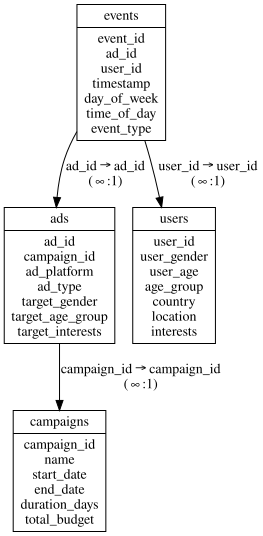

In [90]:
def draw_er_diagram(tables: dict, relations: list, filename="er_diagram"):
    dot = Digraph(comment="ER Diagram")

    # добавляем таблицы
    for table, fields in tables.items():
        # Делаем label в формате record: {Table|field1 \n field2 \n ...}
        label = "{" + table + "|" + "\\n".join(fields) + "}"
        dot.node(table, label, shape="record")

    # добавляем связи
    for left, right, cardinality in relations:
        table1, field1 = left.split(".")
        table2, field2 = right.split(".")
        dot.edge(table1, table2, label=f"{field1} → {field2}\n({cardinality})")

    return dot

tables = dict(zip(names, [df.columns for df in dfs]))


relations = [
    ("events.ad_id", "ads.ad_id", "∞:1"),
    ("events.user_id", "users.user_id", "∞:1"),
    ("ads.campaign_id", "campaigns.campaign_id", "∞:1"),
]

dot = draw_er_diagram(tables, relations)
dot

### 2.2. Качество данных


### Вопрос в зал: что на лекции подразумевалось под качеством данных?

<br>
<details>
<br>

- наличие/отсутствие пропусков
- наличие/отсутствие дублей
- наличие/отсутствие недопустимых значений

</details>

### Вопрос в зал: какие могут быть недопустимые значения в этом датасете?

<br>
<details>
<br>

- `events.day_of_week` не среди Monday ... Sunday
- `users.user_gender` не Female/Male
- `users.user_age` < 0 или > 100   
- `events.timestamp` меньше `campaigns.start_date` по этому `campaign_id`
- `campaigns.duration_days` не равно `campaigns.end_date` - `campaigns.start_date`
- `campaigns.total_budget` < 0
- можно придумать что-то еще
    
</details>

Посмотрим на качество данных в датасете

In [91]:
for df, name in zip(dfs, names):
    print(f'Таблица: {name} \n')

    print("\n=== Пропущенные значения ===")
    print(df.isnull().sum())

    print("\n=== Количество дубликатов по id ===")
    print(df[df.columns[0]].duplicated().sum())
    
    print('•' * 50)

# Преобразуем даты
events['timestamp'] = pd.to_datetime(events['timestamp'])
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'])
campaigns['end_date'] = pd.to_datetime(campaigns['end_date'])

# Преобразуем интересы из строки в массив
if users['interests'].dtype == 'object':
    users['interests'] = users['interests'].apply(lambda s: s.split(', '))
if ads['target_interests'].dtype == 'object':
    ads['target_interests'] = ads['target_interests'].apply(lambda s: s.split(', '))

# Некорректные значения
print('=== Проверка на некорректные значения: ===')

print(f"Все возможные дни недели: {events['day_of_week'].unique()}")
print(f"Все возможные гендеры: {users['user_gender'].unique()}")
print(f"Возраст пользователей в пределах от {users['user_age'].min()} до {users['user_age'].max()}")

df_full = events.merge(ads, on='ad_id', how='left').merge(campaigns, on='campaign_id', how='left')

incorrect_timestamp = df_full[df_full.apply(lambda row: row['timestamp'] < row['start_date'], axis=1)]
print(f'Некорректные значения: пользователь увидел рекламу до рекламной кампании — {len(incorrect_timestamp)}')

# удалим некорректные значения
incorrect_len_company = df_full[
    df_full.apply(lambda row: row['duration_days'] != (row['end_date'] - row['start_date']).days, axis=1)]
print(f'Некорректные значения: не совпадает длина рекламной кампании — {len(incorrect_len_company)}')

incorrect_budget = df_full[df_full['total_budget'] < 0]
print(f'Некорректные значения: отрицательный бюджет рекламной кампании — {len(incorrect_budget)}')

Таблица: events 


=== Пропущенные значения ===
event_id       0
ad_id          0
user_id        0
timestamp      0
day_of_week    0
time_of_day    0
event_type     0
dtype: int64

=== Количество дубликатов по id ===
0
••••••••••••••••••••••••••••••••••••••••••••••••••
Таблица: ads 


=== Пропущенные значения ===
ad_id               0
campaign_id         0
ad_platform         0
ad_type             0
target_gender       0
target_age_group    0
target_interests    0
dtype: int64

=== Количество дубликатов по id ===
0
••••••••••••••••••••••••••••••••••••••••••••••••••
Таблица: campaigns 


=== Пропущенные значения ===
campaign_id      0
name             0
start_date       0
end_date         0
duration_days    0
total_budget     0
dtype: int64

=== Количество дубликатов по id ===
0
••••••••••••••••••••••••••••••••••••••••••••••••••
Таблица: users 


=== Пропущенные значения ===
user_id        0
user_gender    0
user_age       0
age_group      0
country        0
location       0
interests  

> Что мы видим из значительных проблем датасета:
> - несколько дублей в таблице `users`
> - не синхронизированы даты рекламных компаний и даты показов объявлений

Посмотрим на пользователей с дублирующимися строчками

In [92]:
users.groupby('user_id')['user_gender'].count().sort_values().tail()

user_id
0ebd6    2
168cf    2
49c5c    2
c4f8e    2
c8620    2
Name: user_gender, dtype: int64

In [93]:
users[users['user_id'] == '168cf']

,user_id,user_gender,user_age,age_group,country,location,interests
4347,168cf,Other,39,35-44,United Kingdom,New Angelaview,"[health, food]"
7411,168cf,Female,65,55-65,United States,Garciaberg,"[gaming, travel]"


> Видим, что совсем разные соц-дем характеристики, а это значит, что дубли произошли из-за плохого выбора ключа пользователя

> Что будем делать с проблемами датасета:
> - обработаем дубли: так как в таблице с пользователями нет историчности, оставим любую строчку по пользователю
> - вообще в таком случае стоит искать причину такой проблемы: скорее всего, есть глобальная проблема либо в дате показа, либо в датах рекламной кампании. Однако в нашем случае мы удалим такие строчки как некорректные

In [94]:
users = users.groupby('user_id').first().reset_index()
users

,user_id,user_gender,user_age,age_group,country,location,interests
0,00062,Female,16,16-17,France,Davidside,"[photography, art, food]"
1,00067,Male,38,35-44,United States,East Gary,"[travel, gaming, art]"
2,00095,Female,28,25-34,United Kingdom,Port Thomas,"[photography, fashion]"
3,0023e,Female,35,35-44,India,South Lauren,"[lifestyle, fitness, health]"
4,00336,Female,25,25-34,United States,West Michael,[fashion]
...,...,...,...,...,...,...,...
9945,ffd82,Female,41,35-44,Mexico,Vanessamouth,"[technology, fitness, art]"
9946,ffe0f,Male,31,25-34,Australia,Tonyaside,"[fitness, gaming, news]"
9947,ffed3,Male,47,45-54,United Kingdom,Kimberlyburgh,"[health, news]"
9948,fff7c,Male,33,25-34,United States,South Cynthiashire,[lifestyle]


In [95]:
df_full = df_full[~df_full['event_id'].isin(incorrect_timestamp['event_id'])]
df_full.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests,name,start_date,end_date,duration_days,total_budget
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,9,Facebook,Stories,All,All,"[lifestyle, gaming]",Campaign_9_Launch,2025-05-25,2025-07-13,49,40094.07
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,26,Instagram,Carousel,All,18-24,[photography],Campaign_26_Winter,2025-04-01,2025-06-17,77,44538.87
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,10,Instagram,Carousel,All,35-44,"[technology, travel]",Campaign_10_Winter,2025-05-17,2025-07-21,65,19669.27
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,14,Instagram,Image,All,All,[fashion],Campaign_14_Summer,2025-04-15,2025-06-04,50,39849.94
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,2,Instagram,Stories,Female,35-44,"[health, lifestyle]",Campaign_2_Launch,2025-04-16,2025-07-07,82,79342.41


### 2.3. Аномалии и выбросы.

### Вопрос в зал: что можно сделать, чтобы выявить аномалии и выбросы?

<br>
<details>
<br>

- посмотреть `describe`: на минимум/максимум/различия между средним и медианой
- посмотреть на распределения колонок
- построить boxplot'ы
- посмотреть на динамику по датам
    
</details>

Попробуем выявить аномалии и выбросы

In [96]:
display(df_full.describe())

# === Временной ряд: показы всех компаний по дням ===

df_full['date'] = df_full['timestamp'].dt.date
daily_events = df_full.groupby('date')['event_id'].count().reset_index().rename(columns={
    'event_id': 'events_cnt'})
daily_events

fig = px.line(
    daily_events, x='date', y='events_cnt',
    title="Кол-во показов по дням",
    markers=True
)
fig.update_traces(mode="lines+markers")
fig.update_layout(
    xaxis_title="День",
    yaxis_title="Кол-во показов",
    xaxis_tickangle=-45,
    template="plotly_white"
)
fig.show()

# === Распределение стоимостей компаний ===

fig = px.histogram(
    campaigns, x='total_budget',
    nbins=10,
    title="Распределение стоимостей компаний",
    color_discrete_sequence=["#636EFA"]
)
fig.update_layout(
    xaxis_title="Бюджет",
    yaxis_title="Количество компаний",
    bargap=0.05,
    template="plotly_white"
)
fig.add_vline(x=campaigns['total_budget'].mean(), line_dash="dash", line_color="red", 
              annotation_text="Среднее")
fig.show()

# === Boxplot: охват компаний ===

campaign_coverage = df_full.groupby('ad_id')['user_id'].nunique().reset_index().rename(
    columns={'user_id': 'users_cnt'})

fig = px.box(
    campaign_coverage, y="users_cnt",
    points="all",
    template="plotly_white",
    title='Охват по компаниям'
)
fig.update_traces(quartilemethod="inclusive")
fig.update_layout(
    yaxis_title="Охват"
)
fig.show()

,event_id,ad_id,timestamp,campaign_id,start_date,end_date,duration_days,total_budget
count,333422.000000,333422.000000,333422,333422.000000,333422,333422,333422.000000,333422.000000
mean,200075.880203,98.493426,2025-06-26 06:19:54.389245184,24.494284,2025-04-20 20:18:36.941293568,2025-06-25 18:32:16.356929536,65.926151,53812.857846
min,1.000000,1.000000,2025-05-07 14:11:57,1.000000,2025-02-13 00:00:00,2025-04-02 00:00:00,32.000000,7918.040000
25%,100101.250000,49.000000,2025-06-05 07:34:02,13.000000,2025-03-30 00:00:00,2025-05-23 00:00:00,52.000000,35743.400000
50%,200021.500000,98.000000,2025-06-27 18:19:18.500000,24.000000,2025-04-21 00:00:00,2025-06-30 00:00:00,69.000000,53303.550000
75%,300115.750000,149.000000,2025-07-18 14:18:54.249999872,37.000000,2025-05-18 00:00:00,2025-07-23 00:00:00,82.000000,73911.290000
max,400000.000000,200.000000,2025-08-06 14:11:30,50.000000,2025-07-23 00:00:00,2025-10-12 00:00:00,90.000000,98904.660000
std,115497.899709,57.765528,NaN,13.381008,NaN,NaN,17.187925,25366.022740


In [97]:
df_full['timestamp'].min(), df_full['timestamp'].max()

(Timestamp('2025-05-07 14:11:57'), Timestamp('2025-08-06 14:11:30'))

- Во временном ряде кол-ва показов выбросы вниз в первый и последний день, но это потому, что в эти дни данные доступны не за весь день. В остальном виден восходящий тренд
- В распределении стоимостей компаний выбросов нет: они распределены между 0 и 100000
- В распределении охватов по компаниям есть более и менее популярные кампании: между ними разница чуть меньше, чем на 1 порядок: 300 против 1900. Выбросов нет

### 2.4. Связи между переменными

Есть множество способов найти связи между переменными:

- нахождение корреляций
- применение сегментного анализа
- построение графика важности ML-моделей
- изучение коэффициентов линейной регрессии

В этом семинаре мы разберем корреляционный метод и сегментный анализ, а в последующих — остальные методы.

### 2.4.1. Корреляционный анализ

## Дисклеймер:

> Мы будем работать с корреляцией Пирсона. Она учитывает линейную связь между показателями, а также не устойчива к выбросам. На практике обычно себя лучше показывает корреляция Спирмена (и иногда корреляция Кендала). Рекомендуется прочитать про эти коэффициенты [на вики](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%80%D1%80%D0%B5%D0%BB%D1%8F%D1%86%D0%B8%D1%8F#%D0%9D%D0%B5%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B5_%D0%BF%D0%BE%D0%BA%D0%B0%D0%B7%D0%B0%D1%82%D0%B5%D0%BB%D0%B8_%D0%BA%D0%BE%D1%80%D1%80%D0%B5%D0%BB%D1%8F%D1%86%D0%B8%D0%B8)

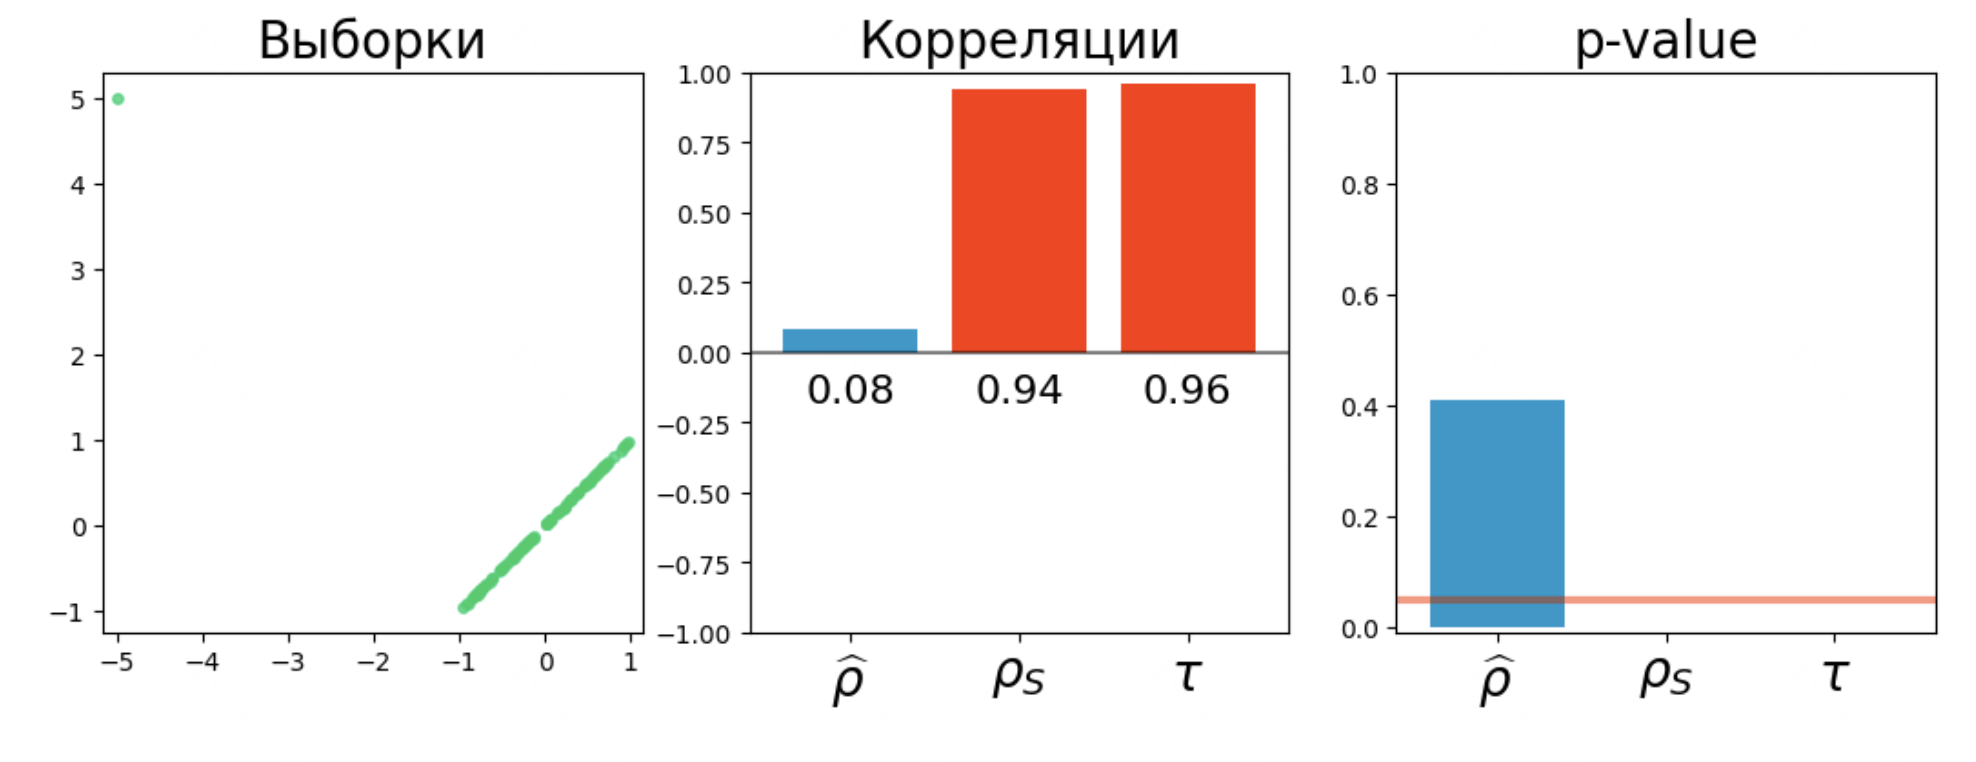

### Интерактив: игра "угадай корреляцию"

Заходим на [сайт](https://www.guessthecorrelation.com/) и играем

### Возвращаемся к кейсу

Будем искать корреляции между успешностью кампании, ее длительностью и бюджетом. Под успешностью будем подразумевать охват и долю кликов

In [98]:
df_click = df_full[df_full['event_type'] == 'Click']
campaigns_stat_agg = df_full.groupby('campaign_id')['user_id'].nunique().reset_index().rename(
    columns={'user_id': 'users_cnt'})
campaigns_clicks = df_click.groupby('campaign_id')['user_id'].nunique().reset_index().rename(
    columns={'user_id': 'clicks_cnt'})
campaigns_stat_agg = campaigns_stat_agg.merge(campaigns_clicks, on='campaign_id', how='left').fillna(0)
campaigns_stat_agg['click_conv'] = campaigns_stat_agg['clicks_cnt'] / campaigns_stat_agg['users_cnt']
campaigns_stat_agg = campaigns_stat_agg.merge(campaigns[['campaign_id', 'duration_days', 'total_budget']], 
                                              on='campaign_id').set_index('campaign_id')

In [99]:
# === 6. Корреляционная матрица (2 знака) ===

corr = campaigns_stat_agg.select_dtypes(include=np.number).corr().round(2)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Корреляционная матрица"
)
fig.update_layout(
    xaxis_title="Признаки",
    yaxis_title="Признаки",
    template="plotly_white"
)
fig.show()

- Основные метрики (`users_cnt`, `clicks_cnt`, `click_conv`) сильно связаны между собой
- Продолжительность кампании (`duration_days`) не играет роли
- Бюджет (`total_budget`) влияет, но не сильно

### 2.4.2. Сегментный анализ

Напомним, что **сегментация** — это метод, в котором мы ищем разрезы, в которых отличаются ключевые показатели. 
Мы хотим понять, какие показатели влияют на охват рекламной кампании и конверсию в клик.

Для начала нам нужно определить метрики, которые могут влиять на показатели

### Вопрос в зал: что может влиять на охват и конверсию в клик?

<br>
<details>
<br>

- как мы уже выяснили, бюджет
- совпадение интересов пользователя и кампании
- совпадение возрастной группы пользователя и кампании
- совпадение пола пользователя и кампании
- время показа рекламы
    
</details>

- Пойдем с самого очевидного: разделим бюджет кампании на группы до 35 тыс., 35-65 тыс. и более 65 тыс. и посмотрим в 

In [236]:
campaigns_stat_agg['budget_rank'] = campaigns_stat_agg['total_budget'].apply(
    lambda x: 0 if x < 35000 else 1 if x < 65000 else 2)

# === 5. Boxplot: продажи по сегментам ===

fig = px.box(
    campaigns_stat_agg, x="budget_rank", y="users_cnt", color="budget_rank",
    title="Boxplot охватов по уровню бюджета",
    points="all",
    template="plotly_white"
)
fig.update_traces(quartilemethod="inclusive")
fig.update_layout(
    xaxis_title="Уровень бюджета",
    yaxis_title="Охват"
)
fig.show()

fig = px.box(
    campaigns_stat_agg, x="budget_rank", y="click_conv", color="budget_rank",
    title="Boxplot конверсий в клик по уровню бюджета",
    points="all",
    template="plotly_white"
)
fig.update_traces(quartilemethod="inclusive")
fig.update_layout(
    xaxis_title="Уровень бюджета",
    yaxis_title="Конверсия в клик"
)
fig.show()

> Стоит заметить, что точек довольно мало, но в обоих случаях одинаковые паттерны поведения: "дешевые" кампании приносят довольно маленькие охваты и конверсии, а кампании дороже 35 тыс. приносят больше пользователей и кликов. При этом разницы между "дорогой" и "средней по цене" кампаниями не наблюдается 

- Перейдем к сравнению интересов. Посмотрим на конверсию в клик среди интересов, совпадающих и не совпадающих с рекламной компанией

Для начала сделаем one-hot интересов пользователей и реклам.

In [172]:
one_hot = users["interests"].explode().str.get_dummies().groupby(level=0).sum()
# Объединяем с исходным датафреймом
users_one_hot = users.drop(columns=["interests"]).join(one_hot)

one_hot_ads = pd.get_dummies(ads["target_interests"].explode(), prefix='target').groupby(level=0).sum()
ads_with_one_hot = ads[['ad_id']].join(one_hot_ads)
df_full_one_hot = df_full.drop(columns=["target_interests"]).merge(ads_with_one_hot, on='ad_id', how='left')
df_full_users = df_full_one_hot.merge(users_one_hot, on='user_id', how='left')
df_full_users.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id,ad_platform,ad_type,...,fitness,food,gaming,health,lifestyle,news,photography,sports,technology,travel
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,9,Facebook,Stories,...,0,1,1,0,0,0,0,0,0,0
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,26,Instagram,Carousel,...,0,0,0,0,0,0,1,0,0,0
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,10,Instagram,Carousel,...,0,0,0,0,0,0,0,1,0,1
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,14,Instagram,Image,...,0,1,0,0,0,0,0,0,0,0
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,2,Instagram,Stories,...,0,0,0,0,1,0,0,0,0,0


In [173]:
interests = users['interests'].explode().unique()

df_full_users['interest_coincedence'] = 0
for interest in interests:
    df_full_users['interest_coincedence'] += (df_full_users[interest] * df_full_users[f'target_{interest}'])
        
df_full_users.loc[df_full_users['interest_coincedence'] > 0, 'interest_coincedence'] = 1
df_full_users.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id,ad_platform,ad_type,...,food,gaming,health,lifestyle,news,photography,sports,technology,travel,interest_coincedence
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,9,Facebook,Stories,...,1,1,0,0,0,0,0,0,0,1
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,26,Instagram,Carousel,...,0,0,0,0,0,1,0,0,0,1
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,10,Instagram,Carousel,...,0,0,0,0,0,0,1,0,1,1
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,14,Instagram,Image,...,1,0,0,0,0,0,0,0,0,0
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,2,Instagram,Stories,...,0,0,0,1,0,0,0,0,0,1


In [183]:
def segment_analysis(df, group_cols, segment_col, user_col='user_id', 
                     event_col='event_type', event_type='Click'):
    df_group = df.groupby(group_cols)[user_col].nunique().reset_index().rename(columns={
        user_col: 'users_cnt'})
    
    df_conv = df[df[event_col] == event_type]
    df_group_conv = df_conv.groupby(group_cols)[user_col].nunique().reset_index().rename(columns={
        user_col: f'{event_type}_cnt'})
    df_group = df_group.merge(df_group_conv, on=group_cols)
    df_group[f'{event_type}_conv'] = df_group[f'{event_type}_cnt'] / df_group['users_cnt']
    
    fig = px.box(
        df_group, x=segment_col, y=f'{event_type}_conv', color=segment_col,
        title=f"Boxplot конверсий в {event_type} по {segment_col}",
        points="all",
        template="plotly_white"
    )
    fig.update_traces(quartilemethod="inclusive")
    fig.update_layout(
        xaxis_title=segment_col,
        yaxis_title=f'Конверсия в {event_type}'
    )
    fig.show()

In [184]:
segment_analysis(df_full_users, ['ad_id', 'interest_coincedence'], 'interest_coincedence')

### Вопрос в зал: есть связь? Почему у элементов с совпадением интересов больше дисперсия?

<br>
<details>
<br>

Кажется, что связи нет. Дисперсия больше, потому что элементов с совпадением интересов меньше. Вспоминаем начало семинара про бутстреп 🙃
    
</details>

- Возраст и совпадение возраста с рекламной компанией

In [185]:
segment_analysis(df_full_users, ['ad_id', 'age_group'], 'age_group')

In [186]:
df_full_users['age_coincedence'] = (df_full_users['target_age_group'] == 'All').astype(int)
df_full_users['age_coincedence'] += (df_full_users['age_group'] == df_full_users['target_age_group'])

df_full_users.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id,ad_platform,ad_type,...,gaming,health,lifestyle,news,photography,sports,technology,travel,interest_coincedence,age_coincedence
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,9,Facebook,Stories,...,1,0,0,0,0,0,0,0,1,1
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,26,Instagram,Carousel,...,0,0,0,0,1,0,0,0,1,0
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,10,Instagram,Carousel,...,0,0,0,0,0,1,0,1,1,0
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,14,Instagram,Image,...,0,0,0,0,0,0,0,0,0,1
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,2,Instagram,Stories,...,0,0,1,0,0,0,0,0,1,0


In [187]:
segment_analysis(df_full_users, ['ad_id', 'age_coincedence'], 'age_coincedence')

> По возрасту есть ощущение, что реклама лучше влияет на более людей 45+, однако старшего поколения поменьше, так это не такая сильная гипотеза

> По совпадению возраста человека и рекламной кампании не видна связь с конверсией в клик

- По полу

In [188]:
segment_analysis(df_full_users, ['ad_id', 'user_gender'], 'user_gender')

> По полу человека взаимосвязи с конверсией в клик не наблюдается

### Практика: используя функцию, визуализируйте боксплот по времени дня взаимодействия с рекламой и сделайте вывод

In [190]:
...

Ellipsis

In [191]:
segment_analysis(df_full_users, ['ad_id', 'time_of_day'], 'time_of_day')

> По времени взаимодействия с рекламой связи тоже нет

### 2.5. Анализ воронки

### Вопрос в зал: перед вами ивенты, которые могут быть. Какие можно выделить стадии воронки?

In [192]:
df_full_users['event_type'].value_counts()

event_type
Impression    283275
Click          33419
Like            9949
Comment         3443
Purchase        1686
Share           1650
Name: count, dtype: int64

<br>
<details>
<br>

Предлагается выделить следующие этапы воронки:
    
- показ (`Impression`)
- клик (`Click`)
- взаимодействие (`Like`, `Comment`, `Share`)
- покупка (`Purchase`)
    
</details>

In [196]:
df_full_users['event_level'] = df_full_users['event_type'].apply(lambda t: 0 if t == 'Impression' \
                                                                 else 1 if t == 'Click' \
                                                                 else 2 if t in ['Like', 'Comment', 'Share'] \
                                                                 else 3)
df_full_users.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id,ad_platform,ad_type,...,health,lifestyle,news,photography,sports,technology,travel,interest_coincedence,age_coincedence,event_level
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,9,Facebook,Stories,...,0,0,0,0,0,0,0,1,1,2
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,26,Instagram,Carousel,...,0,0,0,1,0,0,0,1,0,2
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,10,Instagram,Carousel,...,0,0,0,0,1,0,1,1,0,0
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,14,Instagram,Image,...,0,0,0,0,0,0,0,0,1,0
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,2,Instagram,Stories,...,0,1,0,0,0,0,0,1,0,0


Посмотрим на связь конверсий в воронке в зависимости от платформы и от типа рекламы

In [198]:
df_ad_group = df_full_users.groupby(['user_id', 'ad_id'])['event_level'].max().reset_index()
df_ad_group = df_ad_group.merge(ads, on='ad_id')
df_ad_group

,user_id,ad_id,event_level,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,00062,2,1,33,Facebook,Stories,All,25-34,"[travel, photography]"
1,00336,2,0,33,Facebook,Stories,All,25-34,"[travel, photography]"
2,00567,2,0,33,Facebook,Stories,All,25-34,"[travel, photography]"
3,006ce,2,0,33,Facebook,Stories,All,25-34,"[travel, photography]"
4,007b8,2,0,33,Facebook,Stories,All,25-34,"[travel, photography]"
...,...,...,...,...,...,...,...,...,...
304619,ff30f,119,0,44,Instagram,Carousel,All,35-44,[health]
304620,ff3b2,119,0,44,Instagram,Carousel,All,35-44,[health]
304621,ff50e,119,1,44,Instagram,Carousel,All,35-44,[health]
304622,ff8e1,119,0,44,Instagram,Carousel,All,35-44,[health]


In [218]:
df_ad_group_platform = df_ad_group.groupby(['ad_platform', 'event_level'])[
    'user_id'].count().reset_index().rename(columns={'user_id': 'user_cnt'})
df_ad_group_platform["user_cnt"] = (
    df_ad_group_platform.sort_values("event_level", ascending=False).groupby(
        "ad_platform")["user_cnt"].cumsum())
# Максимум (уровень 0) на каждую платформу
df_ad_group_platform["total"] = df_ad_group_platform.groupby("ad_platform")["user_cnt"].transform("max")

# Процент от верхнего уровня
df_ad_group_platform["conversion_rate"] = np.round(
    df_ad_group_platform["user_cnt"] / df_ad_group_platform["total"], 4)
df_ad_group_platform

,ad_platform,event_level,user_cnt,total,conversion_rate
0,Facebook,0,202518,202518,1.0000
1,Facebook,1,32902,202518,0.1625
2,Facebook,2,11048,202518,0.0546
3,Facebook,3,1143,202518,0.0056
4,Instagram,0,102106,102106,1.0000
5,Instagram,1,16633,102106,0.1629
6,Instagram,2,5615,102106,0.0550
7,Instagram,3,543,102106,0.0053


In [232]:
data = dict(Quantity=df_ad_group_platform['conversion_rate'],
            Stage=['Показы', 'Клики', 'Взаимодействия', 'Покупки']*2,
            Process=df_ad_group_platform['ad_platform'])
    
fig = px.funnel(data, y='Stage', x='Quantity', color='Process',
                color_discrete_map={"Старый": "#374B53", 
                                    "Новый": "#A4B7C8"},
                template="simple_white",
                title='Сравнение разных каналов рекламы',
                labels={"Stage": ""})

fig.update_traces(textinfo="percent initial", textfont=dict(size=16))

fig.show()

In [234]:
df_ad_group_type = df_ad_group.groupby(['ad_type', 'event_level'])[
    'user_id'].count().reset_index().rename(columns={'user_id': 'user_cnt'})
df_ad_group_type["user_cnt"] = (
    df_ad_group_type.sort_values("event_level", ascending=False).groupby(
        "ad_type")["user_cnt"].cumsum())
# Максимум (уровень 0) на каждую платформу
df_ad_group_type["total"] = df_ad_group_type.groupby("ad_type")["user_cnt"].transform("max")

# Процент от верхнего уровня
df_ad_group_type["conversion_rate"] = np.round(
    df_ad_group_type["user_cnt"] / df_ad_group_type["total"], 4)
df_ad_group_type

,ad_type,event_level,user_cnt,total,conversion_rate
0,Carousel,0,75246,75246,1.0000
1,Carousel,1,12094,75246,0.1607
2,Carousel,2,4094,75246,0.0544
3,Carousel,3,420,75246,0.0056
4,Image,0,81595,81595,1.0000
5,Image,1,13312,81595,0.1631
6,Image,2,4436,81595,0.0544
7,Image,3,436,81595,0.0053
8,Stories,0,97647,97647,1.0000
9,Stories,1,15936,97647,0.1632


In [235]:
def plot_funnel(funnel_df=df_ad_group_type, segment_col='ad_type', title='Сравнение по типу рекламы'):
    fig = px.bar(
        funnel_df,
        x="event_level",
        y="conversion_rate",
        color=segment_col,
        barmode="group",
        color_discrete_sequence=px.colors.qualitative.Vivid
    )
    fig.update_layout(
        title=title,
        yaxis_title="Конверсия (%)",
        xaxis_title="Этап",
        template="plotly_white",
        bargap=0.2
    )
    fig.show()

# Визуализация
plot_funnel()

> Кажется, нет влияния на конверсии ни платформы, ни типа взаимодействия.

### 2.6. Вывод по кейсу

* Данные по показам: тренд растущий, выбросы только из-за неполных дней.
* Основные метрики (`users_cnt`, `clicks_cnt`, `click_conv`) движутся синхронно.
* Продолжительность кампании значения не имеет.
* Бюджет оказывает умеренное влияние: "дешёвые" кампании → низкий охват, дорогие (>35k) → выше, но прирост с ростом бюджета после порога небольшой.
* Возраст: лучше откликаются 45+, но таких пользователей меньше.
* Ни пол, ни интересы, ни платформа, ни время суток не влияют на конверсии.

### Практика: сформулируйте гипотезы, которые можно сделать из этих выводов

<br>
<details>
<br>

1. *Оптимизация бюджета:* если мы **будем удерживать бюджет кампаний в среднем диапазоне (35-50k)**, то получим **увеличение охвата и кликов**. Действие замерим через **охват** и **конверсию в клик**, которые вырастут на **7–10%** по сравнению с низкобюджетными кампаниями.

2. **Фокус на аудитории 45+:** **если мы нацелим часть кампаний на пользователей 45+**, то повысим **конверсию из показа в клик** в этом сегменте. Действие заметим через **CTR**, который увеличится на **5–7%** для этой аудитории.

3. **Сокращение неэффективных параметров** если мы **перестанем тратить время на настройку по полу, интересам, платформам и времени суток**, то сохраним ресурсы и не потеряем эффективность. Действие заметим через **стабильность CTR и CR** (без падения, **изменения ≤1%)**.
</details>

## 3. Итоги семинара

- разобрались на практике, что значит понимать структуру данных и оценивать их качество
- проверили данные на "адекватность", нашли некорректные значения
- попробовали выявить аномалии и выбросы через боксплоты, построение распределений и динамики метрики во времени
- провели первичный анализ данных: посмотрели корреляции между параметрами, поработали с сегментным анализом и с воронкой
- сформировали гипотезы из EDA

## 4. Полезные материалы

- [Игра: угадай корреляцию](https://www.guessthecorrelation.com/)
- [Статья про странные корреляции](https://habr.com/ru/articles/236503/)